<a href="https://colab.research.google.com/github/zaheeer1209/Data-Science-projects/blob/main/TIME_SERIES_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

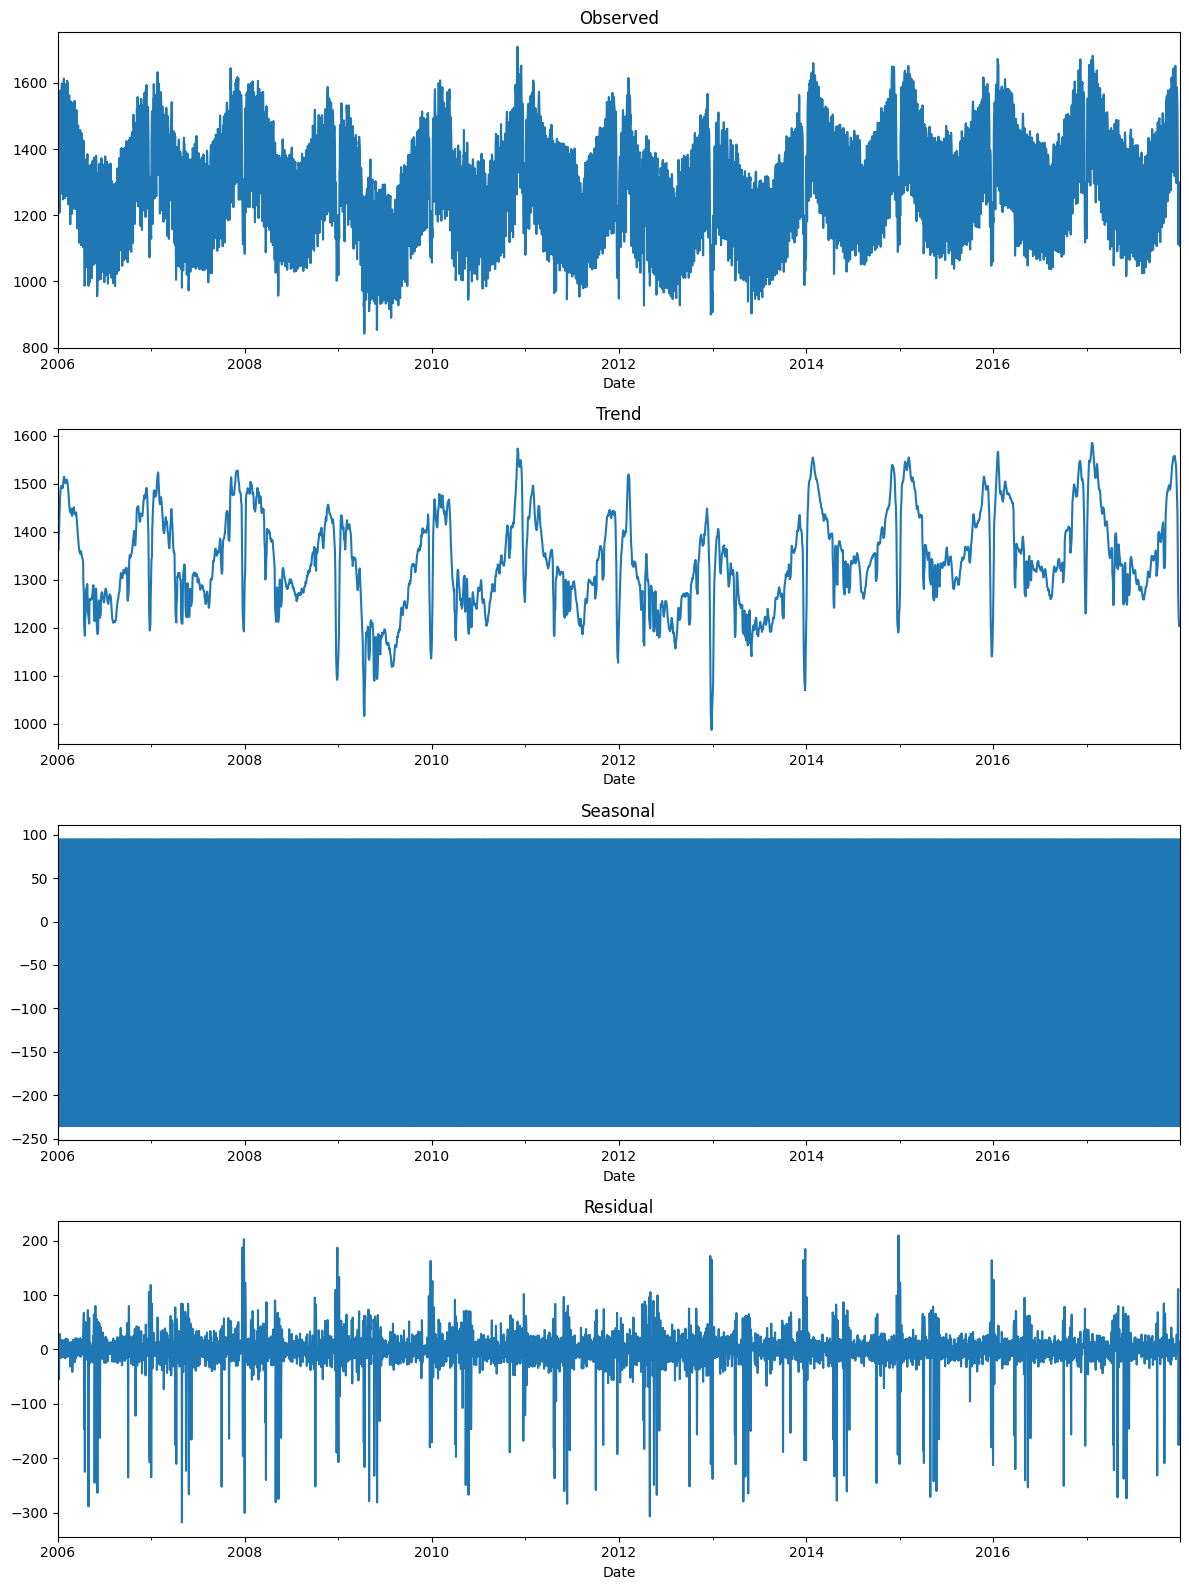

ADF Statistic: -6.239148288864467
p-value: 4.74405490184287e-08
Critical Values: {'1%': np.float64(-3.4318538295011636), '5%': np.float64(-2.8622045082106773), '10%': np.float64(-2.5671237222704466)}


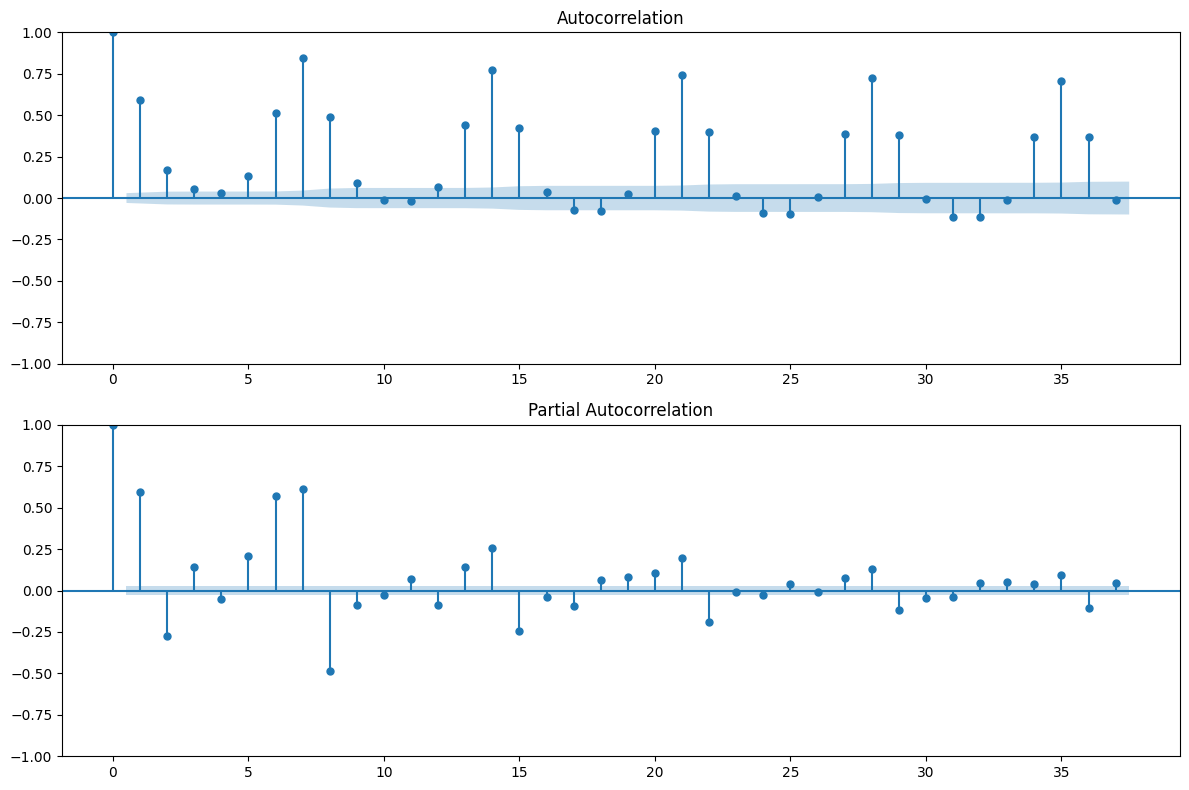

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the data
def load_data(file_path):
    # Check file extension and load accordingly
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    elif file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path, parse_dates=['Date'], index_col='Date')
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    return df

# Perform time series decomposition
def decompose_series(series, model='additive'):
    result = seasonal_decompose(series, model=model)
    return result

# Check stationarity using Augmented Dickey-Fuller test
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])

# Plot time series components
def plot_components(result):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
    result.observed.plot(ax=ax1)
    ax1.set_title('Observed')
    result.trend.plot(ax=ax2)
    ax2.set_title('Trend')
    result.seasonal.plot(ax=ax3)
    ax3.set_title('Seasonal')
    result.resid.plot(ax=ax4)
    ax4.set_title('Residual')
    plt.tight_layout()
    plt.show()

# Plot ACF and PACF
def plot_acf_pacf(series):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(series, ax=ax1)
    plot_pacf(series, ax=ax2)
    plt.tight_layout()
    plt.show()

# Main function
def main():
    # Load data (replace with your file path)
    df = load_data('/content/opsd_germany_daily.xlsx')
    # Select a column for analysis (e.g., 'Consumption')
    series = df['Consumption']
    # Perform decomposition
    result = decompose_series(series)
    # Plot components
    plot_components(result)
    # Check stationarity
    check_stationarity(series)
    # Plot ACF and PACF
    plot_acf_pacf(series)

main()